# Airline Customer Value Data Analysis

## Project Overview

**Objective:** Segment 62K+ airline loyalty customers and predict churn risk for high-value segments.

**Dataset:** Airline frequent flyer program data with 44 features including flight frequency, mileage, membership duration, and points activity.

**Methods:**
- **Part 1 - Customer Segmentation:** K-Means clustering evaluated by Silhouette Score (optimal k=6) and Calinski-Harabasz Index (optimal k=4); selected k=5 as a business-driven compromise to identify 5 distinct customer segments
- **Part 2 - Churn Prediction:** LSTM neural network to predict churn probability for high-value customers

**Business Value:** Enable targeted marketing strategies and proactive retention for at-risk valuable customers.

In [1]:
import pandas as pd
import numpy as np
airline_data=pd.read_csv('air_data.csv'
                         ,encoding='gb18030')

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
airline_data.head()

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,...,ADD_Point_SUM,Eli_Add_Point_Sum,L1Y_ELi_Add_Points,Points_Sum,L1Y_Points_Sum,Ration_L1Y_Flight_Count,Ration_P1Y_Flight_Count,Ration_P1Y_BPS,Ration_L1Y_BPS,Point_NotFlight
0,54993,2006/11/2,2008/12/24,男,6,.,北京,CN,31.0,2014/3/31,...,39992,114452,111100,619760,370211,0.509524,0.490476,0.487221,0.512777,50
1,28065,2007/2/19,2007/8/3,男,6,NaN,北京,CN,42.0,2014/3/31,...,12000,53288,53288,415768,238410,0.514286,0.485714,0.489289,0.510708,33
2,55106,2007/2/1,2007/8/30,男,6,.,北京,CN,40.0,2014/3/31,...,15491,55202,51711,406361,233798,0.518519,0.481481,0.481467,0.518530,26
3,21189,2008/8/22,2008/8/23,男,5,Los Angeles,CA,US,64.0,2014/3/31,...,0,34890,34890,372204,186100,0.434783,0.565217,0.551722,0.448275,12
4,39546,2009/4/10,2009/4/15,男,6,贵阳,贵州,CN,48.0,2014/3/31,...,22704,64969,64969,338813,210365,0.532895,0.467105,0.469054,0.530943,39


In [4]:
columns_set = set(airline_data.columns)
print(columns_set)

{'ADD_POINTS_SUM_YR_1', 'WEIGHTED_SEG_KM', 'LOAD_TIME', 'L1Y_ELi_Add_Points', 'EP_SUM', 'ADD_POINTS_SUM_YR_2', 'P1Y_BP_SUM', 'SUM_YR_2', 'WORK_CITY', 'FFP_TIER', 'AGE', 'EXCHANGE_COUNT', 'MAX_INTERVAL', 'LAST_TO_END', 'Ration_P1Y_Flight_Count', 'Ration_L1Y_Flight_Count', 'Eli_Add_Point_Sum', 'SEG_KM_SUM', 'BP_SUM', 'WORK_COUNTRY', 'FIRST_FLIGHT_DATE', 'EP_SUM_YR_2', 'FFP_DATE', 'SUM_YR_1', 'avg_discount', 'L1Y_BP_SUM', 'BEGIN_TO_FIRST', 'Point_NotFlight', 'ADD_Point_SUM', 'Points_Sum', 'P1Y_Flight_Count', 'AVG_INTERVAL', 'WORK_PROVINCE', 'L1Y_Flight_Count', 'L1Y_Points_Sum', 'MEMBER_NO', 'GENDER', 'AVG_FLIGHT_COUNT', 'Ration_P1Y_BPS', 'Ration_L1Y_BPS', 'EP_SUM_YR_1', 'LAST_FLIGHT_DATE', 'AVG_BP_SUM', 'FLIGHT_COUNT'}


###  Descriptive Data Analysis

In [5]:
airline_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62988 entries, 0 to 62987
Data columns (total 44 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   MEMBER_NO                62988 non-null  int64  
 1   FFP_DATE                 62988 non-null  object 
 2   FIRST_FLIGHT_DATE        62988 non-null  object 
 3   GENDER                   62985 non-null  object 
 4   FFP_TIER                 62988 non-null  int64  
 5   WORK_CITY                60719 non-null  object 
 6   WORK_PROVINCE            59740 non-null  object 
 7   WORK_COUNTRY             62962 non-null  object 
 8   AGE                      62568 non-null  float64
 9   LOAD_TIME                62988 non-null  object 
 10  FLIGHT_COUNT             62988 non-null  int64  
 11  BP_SUM                   62988 non-null  int64  
 12  EP_SUM_YR_1              62988 non-null  int64  
 13  EP_SUM_YR_2              62988 non-null  int64  
 14  SUM_YR_1              

**Observations:**
- The dataset contains 44 columns (features) in total
- Most columns have 62,988 non-null values, indicating a largely complete dataset
- Key columns with missing values: WORK_CITY, WORK_PROVINCE, AGE, SUM_YR_1, SUM_YR_2
- Missing values in SUM_YR_1 and SUM_YR_2 (ticket prices) may indicate incomplete records and need to be addressed in preprocessing

### Data Preprocessing<br>
#### 1. Remove rows with empty ticket prices


In [6]:
# Ensure both first and second year ticket prices are not empty
exp1=airline_data['SUM_YR_1'].notnull()
exp2=airline_data['SUM_YR_2'].notnull()
exp=exp1&exp2
airline_notnull=airline_data.loc[exp,:]
airline_notnull.shape

(62299, 44)

#### 2. Retain only rows where the ticket price is not zero, the average discount rate is not zero, and the total flight kilometers is greater than zero.

In [7]:
index1=airline_notnull['SUM_YR_1']!=0
index2=airline_notnull['SUM_YR_2']!=0
index3=(airline_notnull['avg_discount']!=0)&(airline_notnull['SEG_KM_SUM']>0)
airline=airline_notnull[(index1|index2)&index3]
airline.shape

(62044, 44)

In [8]:
airline.head()

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,...,ADD_Point_SUM,Eli_Add_Point_Sum,L1Y_ELi_Add_Points,Points_Sum,L1Y_Points_Sum,Ration_L1Y_Flight_Count,Ration_P1Y_Flight_Count,Ration_P1Y_BPS,Ration_L1Y_BPS,Point_NotFlight
0,54993,2006/11/2,2008/12/24,男,6,.,北京,CN,31.0,2014/3/31,...,39992,114452,111100,619760,370211,0.509524,0.490476,0.487221,0.512777,50
1,28065,2007/2/19,2007/8/3,男,6,NaN,北京,CN,42.0,2014/3/31,...,12000,53288,53288,415768,238410,0.514286,0.485714,0.489289,0.510708,33
2,55106,2007/2/1,2007/8/30,男,6,.,北京,CN,40.0,2014/3/31,...,15491,55202,51711,406361,233798,0.518519,0.481481,0.481467,0.518530,26
3,21189,2008/8/22,2008/8/23,男,5,Los Angeles,CA,US,64.0,2014/3/31,...,0,34890,34890,372204,186100,0.434783,0.565217,0.551722,0.448275,12
4,39546,2009/4/10,2009/4/15,男,6,贵阳,贵州,CN,48.0,2014/3/31,...,22704,64969,64969,338813,210365,0.532895,0.467105,0.469054,0.530943,39


### Feature Construction

#### L (Loyalty Duration): LOAD_TIME - FFP_DATE

LOAD_TIME: the end time of the observation window.
FFP_DATE: the date when the customer joined the frequent flyer program.
This difference gives the duration of loyalty and is converted into months for uniformity.

#### R (Recency): LAST_TO_END

LAST_TO_END represents the duration from the last flight to the end of the observation window.

#### F (Frequency): FLIGHT_COUNT 

FLIGHT_COUNT captures the number of flights taken by the customer during the observation window.

#### M (Miles Flown): SEG_KM_SUM

SEG_KM_SUM provides the total number of kilometers flown by the customer during the observation window.

#### C (Average Discount Rate): avg_discount

avg_discount represents the average discount availed, considering the booking class and its corresponding discount rate.

1. Select features based on the LRFMC order, and name it as airline_selection.
2. Construct the L feature by calculating the difference between the end time and join time. Convert to date format using pd.to_datetime() and get the duration in months.
3. Stack the L feature horizontally with the original data and name it airline_features.
4. Standardize the data using standard deviation. Since the five features have varying ranges, name the result airline_features_scaled.

### How to Interpret LRFMC Values

Cluster centers are reported in standardized units (z-scores). Higher or lower 
values carry different business meanings depending on the feature:

| Feature | Direction of "Good" | Interpretation |
|---------|---------------------|----------------|
| **L** (Loyalty Duration) | Higher is better | Longer-tenured members are more loyal |
| **R** (Recency) | Lower is better | Smaller gap since last flight = more active |
| **F** (Frequency) | Higher is better | More flights = higher engagement |
| **M** (Miles Flown) | Higher is better | More kilometers = higher revenue contribution |
| **C** (Discount Rate) | Context-dependent | High C signals price sensitivity / discount reliance |

In [9]:
# Based on LRFMC, select the features and name it as airline_selection
airline_selection=airline[['MEMBER_NO','LOAD_TIME',
                          'FFP_DATE',
                           'LAST_TO_END',
                           'FLIGHT_COUNT',
                           'SEG_KM_SUM',
                           'avg_discount']]
airline_selection.head()

,MEMBER_NO,LOAD_TIME,FFP_DATE,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount
0,54993,2014/3/31,2006/11/2,1,210,580717,0.961639
1,28065,2014/3/31,2007/2/19,7,140,293678,1.252314
2,55106,2014/3/31,2007/2/1,11,135,283712,1.254676
3,21189,2014/3/31,2008/8/22,97,23,281336,1.090870
4,39546,2014/3/31,2009/4/10,5,152,309928,0.970658


In [10]:
airline_selection.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 62044 entries, 0 to 62978
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MEMBER_NO     62044 non-null  int64  
 1   LOAD_TIME     62044 non-null  object 
 2   FFP_DATE      62044 non-null  object 
 3   LAST_TO_END   62044 non-null  int64  
 4   FLIGHT_COUNT  62044 non-null  int64  
 5   SEG_KM_SUM    62044 non-null  int64  
 6   avg_discount  62044 non-null  float64
dtypes: float64(1), int64(4), object(2)
memory usage: 3.8+ MB


## Part 1: Customer Segmentation (K-Means)

In [11]:
# Convert the data types from object to datetime for better date-time operations
airline_selection['LOAD_TIME']=pd.to_datetime(airline_selection['LOAD_TIME'])
airline_selection['FFP_DATE']=pd.to_datetime(airline_selection['FFP_DATE'])

In [12]:
airline_selection.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 62044 entries, 0 to 62978
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   MEMBER_NO     62044 non-null  int64         
 1   LOAD_TIME     62044 non-null  datetime64[ns]
 2   FFP_DATE      62044 non-null  datetime64[ns]
 3   LAST_TO_END   62044 non-null  int64         
 4   FLIGHT_COUNT  62044 non-null  int64         
 5   SEG_KM_SUM    62044 non-null  int64         
 6   avg_discount  62044 non-null  float64       
dtypes: datetime64[ns](2), float64(1), int64(4)
memory usage: 3.8 MB


In [13]:
airline_selection['L'] = (airline_selection['LOAD_TIME'] - airline_selection['FFP_DATE']).dt.days / 30
airline_selection['L'] = np.round(airline_selection['L'], 2)

airline_features = airline_selection[['MEMBER_NO', 'L', 'LAST_TO_END', 'FLIGHT_COUNT', 'SEG_KM_SUM', 'avg_discount']]

In [14]:
airline_features

,MEMBER_NO,L,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount
0,54993,90.20,1,210,580717,0.961639
1,28065,86.57,7,140,293678,1.252314
2,55106,87.17,11,135,283712,1.254676
3,21189,68.23,97,23,281336,1.090870
4,39546,60.53,5,152,309928,0.970658
...,...,...,...,...,...,...
62974,11163,108.30,89,2,368,0.710000
62975,30765,65.37,121,2,368,0.670000
62976,10380,45.40,39,2,1062,0.225000
62977,16372,15.53,464,2,904,0.250000


In [15]:
airline_features.describe()

,MEMBER_NO,L,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount
count,62044.000000,62044.000000,62044.000000,62044.000000,62044.000000,62044.000000
mean,31485.237928,49.623035,172.532703,11.971359,17321.694749,0.722180
std,18188.650537,28.262726,181.526164,14.110619,21052.728111,0.184833
min,1.000000,12.170000,1.000000,2.000000,368.000000,0.136017
25%,15715.750000,24.500000,29.000000,3.000000,4874.000000,0.613085
50%,31476.500000,42.600000,105.000000,7.000000,10200.000000,0.712162
75%,47247.250000,72.730000,260.000000,15.000000,21522.500000,0.809293
max,62988.000000,114.570000,731.000000,213.000000,580717.000000,1.500000


In [16]:
from sklearn.preprocessing import StandardScaler

features_to_scale = ['L', 'LAST_TO_END', 'FLIGHT_COUNT', 'SEG_KM_SUM', 'avg_discount']

scaler = StandardScaler()
airline_features_scaled = airline_features.copy()   # Create a copy to preserve 'MEMBER_NO'
airline_features_scaled[features_to_scale] = scaler.fit_transform(airline_features[features_to_scale])
airline_features_scaled

,MEMBER_NO,L,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount
0,54993,1.435718,-0.944955,14.034129,26.761370,1.295551
1,28065,1.307279,-0.911902,9.073286,13.126970,2.868199
2,55106,1.328508,-0.889866,8.718940,12.653583,2.880973
3,21189,0.658362,-0.416102,0.781591,12.540723,1.994730
4,39546,0.385917,-0.922920,9.923716,13.898848,1.344346
...,...,...,...,...,...,...
62974,11163,2.076142,-0.460173,-0.706662,-0.805303,-0.065898
62975,30765,0.557168,-0.283888,-0.706662,-0.805303,-0.282311
62976,10380,-0.149422,-0.735617,-0.706662,-0.772338,-2.689906
62977,16372,-1.206299,1.605662,-0.706662,-0.779843,-2.554648


In [17]:
print(airline_features_scaled.columns.tolist())
print(airline_features_scaled.describe())

['MEMBER_NO', 'L', 'LAST_TO_END', 'FLIGHT_COUNT', 'SEG_KM_SUM', 'avg_discount']
          MEMBER_NO             L   LAST_TO_END  FLIGHT_COUNT    SEG_KM_SUM  \
count  62044.000000  6.204400e+04  6.204400e+04  6.204400e+04  6.204400e+04   
mean   31485.237928 -2.638596e-16  4.397660e-17  5.863547e-17 -1.026121e-16   
std    18188.650537  1.000008e+00  1.000008e+00  1.000008e+00  1.000008e+00   
min        1.000000 -1.325185e+00 -9.449552e-01 -7.066621e-01 -8.053033e-01   
25%    15715.750000 -8.889177e-01 -7.907062e-01 -6.357929e-01 -5.912676e-01   
50%    31476.500000 -2.484931e-01 -3.720304e-01 -3.523162e-01 -3.382817e-01   
75%    47247.250000  8.175840e-01  4.818479e-01  2.146373e-01  1.995389e-01   
max    62988.000000  2.297991e+00  3.076536e+00  1.424674e+01  2.676137e+01   

       avg_discount  
count  6.204400e+04  
mean   3.957894e-16  
std    1.000008e+00  
min   -3.171335e+00  
25%   -5.902378e-01  
50%   -5.419990e-02  
75%    4.713077e-01  
max    4.208258e+00  


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

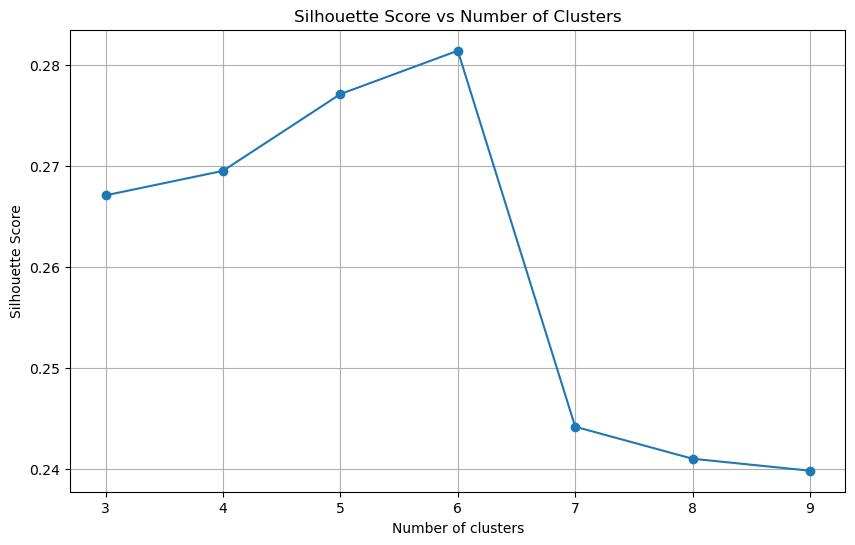

In [19]:
import os
os.environ["OMP_NUM_THREADS"] = "5"
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_range = range(3, 10)
silhouette_scores = []
for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=123, n_init=10)
    kmeans.fit(airline_features_scaled[features_to_scale])      
    cluster_labels = kmeans.labels_
    silhouette_avg = silhouette_score(
        airline_features_scaled[features_to_scale], cluster_labels 
    )
    silhouette_scores.append(silhouette_avg)

plt.figure(figsize=(10, 6))
plt.plot(cluster_range, silhouette_scores, marker='o')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

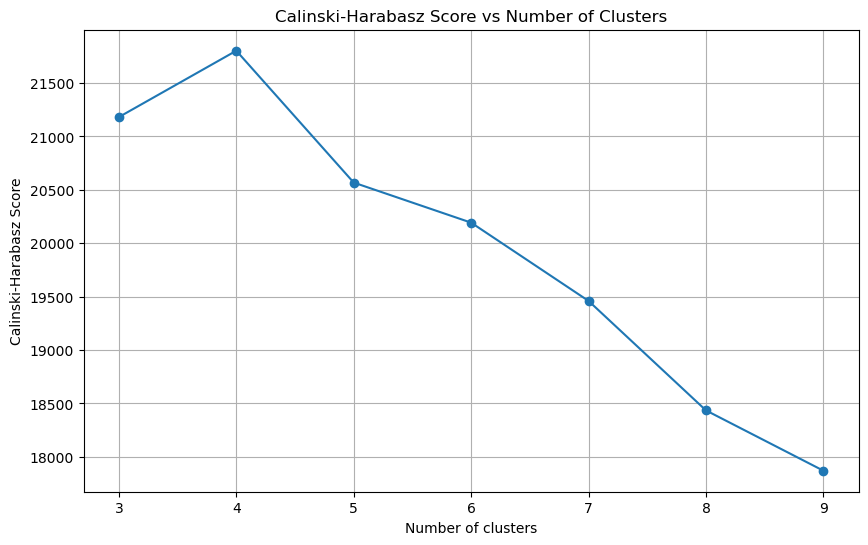

In [20]:
from sklearn.metrics import calinski_harabasz_score

cluster_range = range(3, 10)
ch_scores = []
for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(airline_features_scaled[features_to_scale])  # ← 加
    ch_score = calinski_harabasz_score(airline_features_scaled[features_to_scale], cluster_labels)  # ← 加
    ch_scores.append(ch_score)
    
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, ch_scores, marker='o')
plt.title('Calinski-Harabasz Score vs Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Calinski-Harabasz Score')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

### Using k-means

1. Import the k-means algorithm and initiate model training with an assumption of k=5
2. Obtain cluster labels and cluster centers
3. Count the number of samples in each cluster
4. Evaluate the clustering model and determine the optimal value for k
5. Save cluster center data to a DataFrame and subsequently export to an Excel file

In [21]:
from sklearn.cluster import KMeans

In [22]:
k = 5

kmeans_model = KMeans(n_clusters=k, random_state=123, n_init=10).fit(airline_features_scaled[features_to_scale])

In [23]:
kmeans_model.labels_

array([2, 2, 2, ..., 0, 3, 3])

In [24]:
kmeans_model.cluster_centers_

array([[-0.70027966, -0.41513924, -0.16064317, -0.16034895, -0.25818629],
       [ 1.16106595, -0.37741348, -0.0865308 , -0.09442828, -0.15705928],
       [ 0.48355235, -0.79941328,  2.48315495,  2.42425727,  0.30978729],
       [-0.31307329,  1.68707882, -0.57391045, -0.53672535, -0.17546665],
       [ 0.04103354, -0.00252439, -0.23261276, -0.23699977,  2.16845378]])

In [25]:
df=pd.DataFrame(data=kmeans_model.cluster_centers_)
cluster_names = ['General Developmental Customers', 'High-Value Customers',
                 'VIP Customers', 'General Customers(Potential Churn)', 'Important Retention Customers']
df.index = cluster_names
df.to_csv('df_with_names.csv')
df

,0,1,2,3,4
General Developmental Customers,-0.700280,-0.415139,-0.160643,-0.160349,-0.258186
High-Value Customers,1.161066,-0.377413,-0.086531,-0.094428,-0.157059
VIP Customers,0.483552,-0.799413,2.483155,2.424257,0.309787
General Customers(Potential Churn),-0.313073,1.687079,-0.573910,-0.536725,-0.175467
Important Retention Customers,0.041034,-0.002524,-0.232613,-0.237000,2.168454


In [26]:
s1=pd.Series(kmeans_model.labels_)
label_counts = s1.value_counts().sort_index()
for idx, name in enumerate(cluster_names):
    print(f"{name}: {label_counts[idx]}")

General Developmental Customers: 24611
High-Value Customers: 15728
VIP Customers: 5337
General Customers(Potential Churn): 12111
Important Retention Customers: 4257


In [27]:
airline_features['id']=airline['MEMBER_NO']
airline_features['label']=kmeans_model.labels_
airline_features.head()

,MEMBER_NO,L,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount,id,label
0,54993,90.20,1,210,580717,0.961639,54993,2
1,28065,86.57,7,140,293678,1.252314,28065,2
2,55106,87.17,11,135,283712,1.254676,55106,2
3,21189,68.23,97,23,281336,1.090870,21189,2
4,39546,60.53,5,152,309928,0.970658,39546,2


In [28]:
airline_0=airline_features[airline_features['label']==0]
airline_1=airline_features[airline_features['label']==1]
airline_2=airline_features[airline_features['label']==2]
airline_3=airline_features[airline_features['label']==3]
airline_4=airline_features[airline_features['label']==4]

In [29]:
writer=pd.ExcelWriter('airline.xlsx')
airline_0.to_excel(writer,'General Developmental Customers')
airline_1.to_excel(writer,'High-Value Customers')
airline_2.to_excel(writer,'VIP Customers')
airline_3.to_excel(writer,'General Customers(Potential Churn)')
airline_4.to_excel(writer,'Important Retention Customers')
writer.save()

### Data Visualization: Insight from Enhanced Customer Segmentation

In [30]:
df_with_names = pd.read_csv('df_with_names.csv', index_col=0)
df_with_names

,0,1,2,3,4
General Developmental Customers,-0.700280,-0.415139,-0.160643,-0.160349,-0.258186
High-Value Customers,1.161066,-0.377413,-0.086531,-0.094428,-0.157059
VIP Customers,0.483552,-0.799413,2.483155,2.424257,0.309787
General Customers(Potential Churn),-0.313073,1.687079,-0.573910,-0.536725,-0.175467
Important Retention Customers,0.041034,-0.002524,-0.232613,-0.237000,2.168454


In [31]:
df_with_names.columns = ['LOAD_TIME', 'LAST_TO_END', 'FLIGHT_COUNT', 'SEG_KM_SUM', 'AVG_DISCOUNT']
df_with_names

,LOAD_TIME,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,AVG_DISCOUNT
General Developmental Customers,-0.700280,-0.415139,-0.160643,-0.160349,-0.258186
High-Value Customers,1.161066,-0.377413,-0.086531,-0.094428,-0.157059
VIP Customers,0.483552,-0.799413,2.483155,2.424257,0.309787
General Customers(Potential Churn),-0.313073,1.687079,-0.573910,-0.536725,-0.175467
Important Retention Customers,0.041034,-0.002524,-0.232613,-0.237000,2.168454


In [32]:
df_with_names['Advantage'] = ['R', 'L,R', 'F,M,R', 'None', 'C']
df_with_names['Sample_Count'] = [24611, 15728, 5337, 12111, 4257]
df_with_names['Marketing_Strategy'] = [
    'New customer zone, brand promotion', 
    'Rewards and gratitude for loyal customer', 
    'Enhanced services, word-of-mouth promotion', 
    'Offering coupons', 
    'Retention strategies'
]

df_with_names

,LOAD_TIME,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,AVG_DISCOUNT,Advantage,Sample_Count,Marketing_Strategy
General Developmental Customers,-0.700280,-0.415139,-0.160643,-0.160349,-0.258186,R,24611,"New customer zone, brand promotion"
High-Value Customers,1.161066,-0.377413,-0.086531,-0.094428,-0.157059,"L,R",15728,Rewards and gratitude for loyal customer
VIP Customers,0.483552,-0.799413,2.483155,2.424257,0.309787,"F,M,R",5337,"Enhanced services, word-of-mouth promotion"
General Customers(Potential Churn),-0.313073,1.687079,-0.573910,-0.536725,-0.175467,None,12111,Offering coupons
Important Retention Customers,0.041034,-0.002524,-0.232613,-0.237000,2.168454,C,4257,Retention strategies


In [33]:
df_with_names.index.name = 'Customer Value Labels'
df_with_names.columns = ['LOAD_TIME', 'LAST_TO_END', 'FLIGHT_COUNT', 'SEG_KM_SUM', 'AVG_DISCOUNT', 'Advantage', 'Sample_Count', 'Marketing_Strategy']
df_with_names

,LOAD_TIME,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,AVG_DISCOUNT,Advantage,Sample_Count,Marketing_Strategy
Customer Value Labels,,,,,,,,
General Developmental Customers,-0.700280,-0.415139,-0.160643,-0.160349,-0.258186,R,24611,"New customer zone, brand promotion"
High-Value Customers,1.161066,-0.377413,-0.086531,-0.094428,-0.157059,"L,R",15728,Rewards and gratitude for loyal customer
VIP Customers,0.483552,-0.799413,2.483155,2.424257,0.309787,"F,M,R",5337,"Enhanced services, word-of-mouth promotion"
General Customers(Potential Churn),-0.313073,1.687079,-0.573910,-0.536725,-0.175467,None,12111,Offering coupons
Important Retention Customers,0.041034,-0.002524,-0.232613,-0.237000,2.168454,C,4257,Retention strategies


### Cluster Naming Rationale

Each cluster is named based on which LRFMC dimensions stand out:

| Cluster | Standout Features | Interpretation |
|---------|-------------------|----------------|
| **General Developmental Customers** | Low R (recently flew) but low L/F/M | New members, recently active but haven't built high-value habits yet |
| **High-Value Customers** | High L + active R | Long-tenured members still flying → true loyal base |
| **VIP Customers** | Very high F, M + high L | Top-tier: longest tenure, most flights, most miles |
| **General Customers (Potential Churn)** | No standout advantage; R=+1.69 (long gap since last flight) | Disengaged members at risk of leaving |
| **Important Retention Customers** | Very high C (2.17) only | Discount-dependent / price-sensitive segment |

In [34]:
airline.head()

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,...,ADD_Point_SUM,Eli_Add_Point_Sum,L1Y_ELi_Add_Points,Points_Sum,L1Y_Points_Sum,Ration_L1Y_Flight_Count,Ration_P1Y_Flight_Count,Ration_P1Y_BPS,Ration_L1Y_BPS,Point_NotFlight
0,54993,2006/11/2,2008/12/24,男,6,.,北京,CN,31.0,2014/3/31,...,39992,114452,111100,619760,370211,0.509524,0.490476,0.487221,0.512777,50
1,28065,2007/2/19,2007/8/3,男,6,NaN,北京,CN,42.0,2014/3/31,...,12000,53288,53288,415768,238410,0.514286,0.485714,0.489289,0.510708,33
2,55106,2007/2/1,2007/8/30,男,6,.,北京,CN,40.0,2014/3/31,...,15491,55202,51711,406361,233798,0.518519,0.481481,0.481467,0.518530,26
3,21189,2008/8/22,2008/8/23,男,5,Los Angeles,CA,US,64.0,2014/3/31,...,0,34890,34890,372204,186100,0.434783,0.565217,0.551722,0.448275,12
4,39546,2009/4/10,2009/4/15,男,6,贵阳,贵州,CN,48.0,2014/3/31,...,22704,64969,64969,338813,210365,0.532895,0.467105,0.469054,0.530943,39


In [35]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=123)
airline_features_scaled['cluster'] = kmeans.fit_predict(airline_features_scaled)
airline_features_scaled

,MEMBER_NO,L,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount,cluster
0,54993,1.435718,-0.944955,14.034129,26.761370,1.295551,0
1,28065,1.307279,-0.911902,9.073286,13.126970,2.868199,3
2,55106,1.328508,-0.889866,8.718940,12.653583,2.880973,0
3,21189,0.658362,-0.416102,0.781591,12.540723,1.994730,1
4,39546,0.385917,-0.922920,9.923716,13.898848,1.344346,4
...,...,...,...,...,...,...,...
62974,11163,2.076142,-0.460173,-0.706662,-0.805303,-0.065898,2
62975,30765,0.557168,-0.283888,-0.706662,-0.805303,-0.282311,3
62976,10380,-0.149422,-0.735617,-0.706662,-0.772338,-2.689906,2
62977,16372,-1.206299,1.605662,-0.706662,-0.779843,-2.554648,1


In [36]:
airline_features_scaled['Cluster'] = kmeans_model.labels_

In [37]:
airline_features_scaled

,MEMBER_NO,L,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount,cluster,Cluster
0,54993,1.435718,-0.944955,14.034129,26.761370,1.295551,0,2
1,28065,1.307279,-0.911902,9.073286,13.126970,2.868199,3,2
2,55106,1.328508,-0.889866,8.718940,12.653583,2.880973,0,2
3,21189,0.658362,-0.416102,0.781591,12.540723,1.994730,1,2
4,39546,0.385917,-0.922920,9.923716,13.898848,1.344346,4,2
...,...,...,...,...,...,...,...,...
62974,11163,2.076142,-0.460173,-0.706662,-0.805303,-0.065898,2,1
62975,30765,0.557168,-0.283888,-0.706662,-0.805303,-0.282311,3,1
62976,10380,-0.149422,-0.735617,-0.706662,-0.772338,-2.689906,2,0
62977,16372,-1.206299,1.605662,-0.706662,-0.779843,-2.554648,1,3


In [38]:
airline_features_scaled.rename(columns={'L': 'LOAD_TIME'}, inplace=True)

In [39]:
cluster_mapping = {
    0: 'General Developmental Customers',
    1: 'High-Value Customers',
    2: 'VIP Customers',
    3: 'General Customers(Potential Churn)',
    4: 'Important Retention Customers'
}

airline_features_scaled['Customer Value Labels'] = airline_features_scaled['Cluster'].map(cluster_mapping)
airline_features_scaled

,MEMBER_NO,LOAD_TIME,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount,cluster,Cluster,Customer Value Labels
0,54993,1.435718,-0.944955,14.034129,26.761370,1.295551,0,2,VIP Customers
1,28065,1.307279,-0.911902,9.073286,13.126970,2.868199,3,2,VIP Customers
2,55106,1.328508,-0.889866,8.718940,12.653583,2.880973,0,2,VIP Customers
3,21189,0.658362,-0.416102,0.781591,12.540723,1.994730,1,2,VIP Customers
4,39546,0.385917,-0.922920,9.923716,13.898848,1.344346,4,2,VIP Customers
...,...,...,...,...,...,...,...,...,...
62974,11163,2.076142,-0.460173,-0.706662,-0.805303,-0.065898,2,1,High-Value Customers
62975,30765,0.557168,-0.283888,-0.706662,-0.805303,-0.282311,3,1,High-Value Customers
62976,10380,-0.149422,-0.735617,-0.706662,-0.772338,-2.689906,2,0,General Developmental Customers
62977,16372,-1.206299,1.605662,-0.706662,-0.779843,-2.554648,1,3,General Customers(Potential Churn)


In [40]:
df_with_names.reset_index(inplace=True)
df_with_names

,Customer Value Labels,LOAD_TIME,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,AVG_DISCOUNT,Advantage,Sample_Count,Marketing_Strategy
0,General Developmental Customers,-0.700280,-0.415139,-0.160643,-0.160349,-0.258186,R,24611,"New customer zone, brand promotion"
1,High-Value Customers,1.161066,-0.377413,-0.086531,-0.094428,-0.157059,"L,R",15728,Rewards and gratitude for loyal customer
2,VIP Customers,0.483552,-0.799413,2.483155,2.424257,0.309787,"F,M,R",5337,"Enhanced services, word-of-mouth promotion"
3,General Customers(Potential Churn),-0.313073,1.687079,-0.573910,-0.536725,-0.175467,None,12111,Offering coupons
4,Important Retention Customers,0.041034,-0.002524,-0.232613,-0.237000,2.168454,C,4257,Retention strategies


In [41]:
airline_features_scaled = pd.merge(
    airline_features_scaled, 
    df_with_names[['Customer Value Labels', 'Advantage', 'Sample_Count', 'Marketing_Strategy']],
    on='Customer Value Labels', 
    how='left'
)
airline_features_scaled

,MEMBER_NO,LOAD_TIME,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount,cluster,Cluster,Customer Value Labels,Advantage,Sample_Count,Marketing_Strategy
0,54993,1.435718,-0.944955,14.034129,26.761370,1.295551,0,2,VIP Customers,"F,M,R",5337,"Enhanced services, word-of-mouth promotion"
1,28065,1.307279,-0.911902,9.073286,13.126970,2.868199,3,2,VIP Customers,"F,M,R",5337,"Enhanced services, word-of-mouth promotion"
2,55106,1.328508,-0.889866,8.718940,12.653583,2.880973,0,2,VIP Customers,"F,M,R",5337,"Enhanced services, word-of-mouth promotion"
3,21189,0.658362,-0.416102,0.781591,12.540723,1.994730,1,2,VIP Customers,"F,M,R",5337,"Enhanced services, word-of-mouth promotion"
4,39546,0.385917,-0.922920,9.923716,13.898848,1.344346,4,2,VIP Customers,"F,M,R",5337,"Enhanced services, word-of-mouth promotion"
...,...,...,...,...,...,...,...,...,...,...,...,...
62039,11163,2.076142,-0.460173,-0.706662,-0.805303,-0.065898,2,1,High-Value Customers,"L,R",15728,Rewards and gratitude for loyal customer
62040,30765,0.557168,-0.283888,-0.706662,-0.805303,-0.282311,3,1,High-Value Customers,"L,R",15728,Rewards and gratitude for loyal customer
62041,10380,-0.149422,-0.735617,-0.706662,-0.772338,-2.689906,2,0,General Developmental Customers,R,24611,"New customer zone, brand promotion"
62042,16372,-1.206299,1.605662,-0.706662,-0.779843,-2.554648,1,3,General Customers(Potential Churn),None,12111,Offering coupons


In [42]:
airline_data = pd.merge(
    airline_data,
    airline_features_scaled[['MEMBER_NO', 'LOAD_TIME', 'Customer Value Labels', 'Advantage', 'Sample_Count', 'Marketing_Strategy']],
    on='MEMBER_NO',
    how='left'
)
airline_data.head(10)

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME_x,...,Ration_L1Y_Flight_Count,Ration_P1Y_Flight_Count,Ration_P1Y_BPS,Ration_L1Y_BPS,Point_NotFlight,LOAD_TIME_y,Customer Value Labels,Advantage,Sample_Count,Marketing_Strategy
0,54993,2006/11/2,2008/12/24,男,6,.,北京,CN,31.0,2014/3/31,...,0.509524,0.490476,0.487221,0.512777,50,1.435718,VIP Customers,"F,M,R",5337.0,"Enhanced services, word-of-mouth promotion"
1,28065,2007/2/19,2007/8/3,男,6,NaN,北京,CN,42.0,2014/3/31,...,0.514286,0.485714,0.489289,0.510708,33,1.307279,VIP Customers,"F,M,R",5337.0,"Enhanced services, word-of-mouth promotion"
2,55106,2007/2/1,2007/8/30,男,6,.,北京,CN,40.0,2014/3/31,...,0.518519,0.481481,0.481467,0.518530,26,1.328508,VIP Customers,"F,M,R",5337.0,"Enhanced services, word-of-mouth promotion"
3,21189,2008/8/22,2008/8/23,男,5,Los Angeles,CA,US,64.0,2014/3/31,...,0.434783,0.565217,0.551722,0.448275,12,0.658362,VIP Customers,"F,M,R",5337.0,"Enhanced services, word-of-mouth promotion"
4,39546,2009/4/10,2009/4/15,男,6,贵阳,贵州,CN,48.0,2014/3/31,...,0.532895,0.467105,0.469054,0.530943,39,0.385917,VIP Customers,"F,M,R",5337.0,"Enhanced services, word-of-mouth promotion"
5,56972,2008/2/10,2009/9/29,男,6,广州,广东,CN,64.0,2014/3/31,...,0.456522,0.543478,0.608233,0.391764,15,0.887288,VIP Customers,"F,M,R",5337.0,"Enhanced services, word-of-mouth promotion"
6,44924,2006/3/22,2006/3/29,男,6,乌鲁木齐市,新疆,CN,46.0,2014/3/31,...,0.504950,0.495050,0.495048,0.504948,29,1.701087,VIP Customers,"F,M,R",5337.0,"Enhanced services, word-of-mouth promotion"
7,22631,2010/4/9,2010/4/9,女,6,温州市,浙江,CN,50.0,2014/3/31,...,0.589041,0.410959,0.522078,0.477919,14,-0.043274,VIP Customers,"F,M,R",5337.0,"Enhanced services, word-of-mouth promotion"
8,32197,2011/6/7,2011/7/1,男,5,DRANCY,NaN,FR,50.0,2014/3/31,...,0.410714,0.589286,0.483459,0.516537,7,-0.543230,VIP Customers,"F,M,R",5337.0,"Enhanced services, word-of-mouth promotion"
9,31645,2010/7/5,2010/7/5,女,6,温州,浙江,CN,43.0,2014/3/31,...,0.390625,0.609375,0.526951,0.473044,16,-0.145884,VIP Customers,"F,M,R",5337.0,"Enhanced services, word-of-mouth promotion"


In [43]:
airline_data_sorted = airline_data.sort_values(by='MEMBER_NO')
airline_data_sorted.head(10)

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME_x,...,Ration_L1Y_Flight_Count,Ration_P1Y_Flight_Count,Ration_P1Y_BPS,Ration_L1Y_BPS,Point_NotFlight,LOAD_TIME_y,Customer Value Labels,Advantage,Sample_Count,Marketing_Strategy
19774,1,2006/3/31,2007/1/13,男,4,NaN,NaN,NaN,40.0,2014/3/31,...,1.000000,0.000000,0.000000,0.999858,0,1.690472,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer
10231,2,2006/3/31,2007/2/21,男,4,HONG KONG,NaN,HK,52.0,2014/3/31,...,0.458333,0.541667,0.585590,0.414348,0,1.690472,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer
22550,3,2006/4/7,2006/4/7,女,4,HKG,HKG,CH,52.0,2014/3/31,...,0.333333,0.666667,0.913171,0.086696,5,1.682334,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer
20760,4,2006/8/10,2006/10/17,男,4,广州,广东,CN,45.0,2014/3/31,...,0.333333,0.666667,0.754232,0.245644,13,1.534789,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer
49925,5,2008/2/7,2008/9/11,男,4,NaN,NaN,NaN,57.0,2014/3/31,...,0.333333,0.666667,0.886266,0.113305,0,0.890826,Important Retention Customers,C,4257.0,Retention strategies
48618,6,2010/9/16,2012/12/24,男,4,澳?,澳?,MO,44.0,2014/3/31,...,0.666667,0.333333,0.222083,0.777499,0,-0.231863,General Developmental Customers,R,24611.0,"New customer zone, brand promotion"
57736,7,2011/4/28,2011/8/16,男,4,NaN,NaN,HK,52.0,2014/3/31,...,0.000000,1.000000,0.998217,0.000000,0,-0.496171,General Customers(Potential Churn),None,12111.0,Offering coupons
15005,8,2012/3/9,2012/5/27,男,4,NaN,NaN,HK,63.0,2014/3/31,...,0.750000,0.250000,0.240181,0.759751,0,-0.868750,Important Retention Customers,C,4257.0,Retention strategies
39498,9,2012/8/31,2013/4/9,男,4,NaN,NaN,HK,47.0,2014/3/31,...,1.000000,0.000000,0.000000,0.999788,0,-1.075384,General Developmental Customers,R,24611.0,"New customer zone, brand promotion"
2353,10,2005/9/29,2005/9/29,女,5,NaN,北京,CN,45.0,2014/3/31,...,0.555556,0.444444,0.369240,0.630738,5,1.906306,VIP Customers,"F,M,R",5337.0,"Enhanced services, word-of-mouth promotion"


### Customer Value Label Count Distribution Visualization

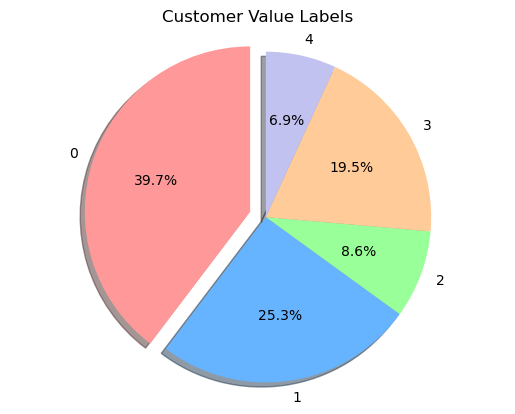

In [44]:
customer_labels = df_with_names.index.tolist()
customer_counts = df_with_names['Sample_Count'].tolist()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']

explode = (0.1, 0, 0, 0, 0)
fig1, ax1 = plt.subplots()
ax1.pie(customer_counts, explode=explode, labels=customer_labels, colors=colors, 
        autopct='%1.1f%%', shadow=True, startangle=90)
ax1.axis('equal')

plt.title('Customer Value Labels')
plt.show()

## Part 2: Churn Prediction (LSTM)


In [45]:
#  LSTM Model, EarlyStopping:

In [46]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [47]:
high_value_customers_df = airline_data[airline_data['Customer Value Labels'] == 'High-Value Customers']
high_value_customers_df

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME_x,...,Ration_L1Y_Flight_Count,Ration_P1Y_Flight_Count,Ration_P1Y_BPS,Ration_L1Y_BPS,Point_NotFlight,LOAD_TIME_y,Customer Value Labels,Advantage,Sample_Count,Marketing_Strategy
1048,11209,2005/6/29,2005/10/15,女,6,广州,广东,CN,40.0,2014/3/31,...,0.444444,0.555556,0.578880,0.421108,3,2.014930,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer
1710,29386,2005/11/30,2006/11/28,男,5,北京,北京,CN,52.0,2014/3/31,...,0.750000,0.250000,0.053524,0.946458,9,1.833064,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer
1763,31130,2009/8/7,2009/8/8,男,4,LANCESTER,PA,US,47.0,2014/3/31,...,0.666667,0.333333,0.116881,0.883099,0,0.245802,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer
1970,57332,2008/5/15,2008/5/15,男,4,广州,广东,CN,60.0,2014/3/31,...,0.666667,0.333333,0.333321,0.666643,0,0.775125,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer
2026,2257,2005/7/20,2005/8/17,女,4,NaN,NaN,NL,45.0,2014/3/31,...,0.230769,0.769231,0.806711,0.193273,3,1.990163,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62956,2213,2005/5/18,2005/7/19,女,4,NaN,NaN,CN,45.0,2014/3/31,...,1.000000,0.000000,0.000000,0.000000,0,2.064466,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer
62960,11699,2008/2/13,2013/7/15,女,4,南宁,广西,CN,73.0,2014/3/31,...,1.000000,0.000000,0.000000,0.000000,0,0.883749,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer
62963,10999,2004/12/16,2004/12/18,女,4,南海市,广东省,CN,60.0,2014/3/31,...,1.000000,0.000000,0.000000,0.997506,0,2.244917,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer
62974,11163,2005/5/8,2005/8/26,男,4,NaN,NaN,CN,34.0,2014/3/31,...,1.000000,0.000000,0.000000,0.997506,1,2.076142,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer


Basic Information
count    15728.000000
mean       104.030900
std         96.009138
min          1.000000
25%         25.000000
50%         76.000000
75%        156.000000
max        535.000000
Name: LAST_TO_END, dtype: float64


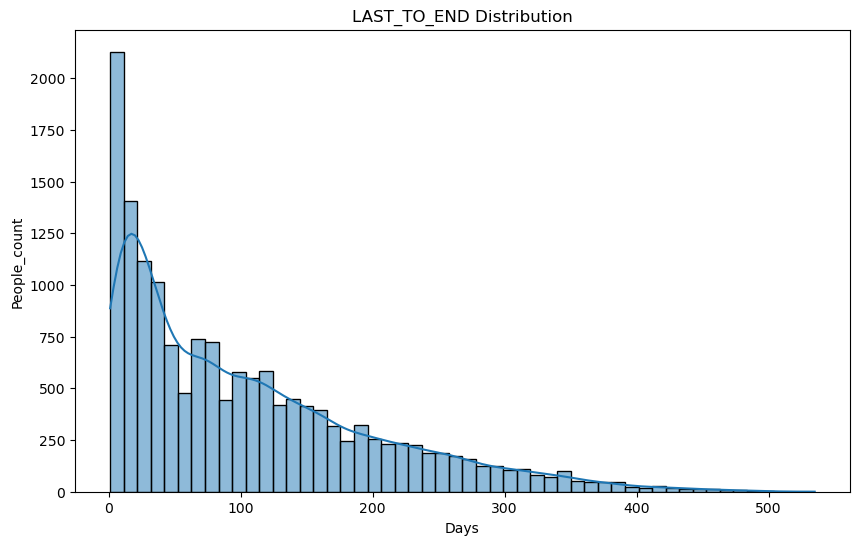

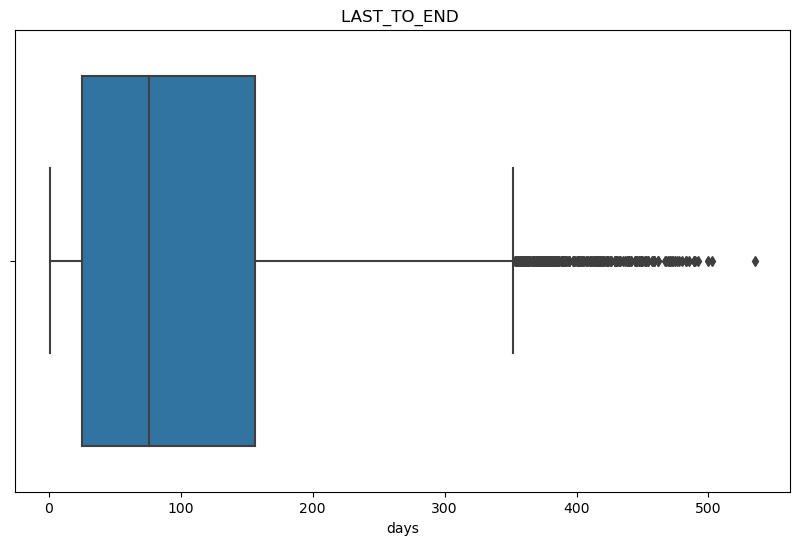

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


print("Basic Information")
print(high_value_customers_df['LAST_TO_END'].describe())


plt.figure(figsize=(10, 6))
sns.histplot(high_value_customers_df['LAST_TO_END'], kde=True)
plt.title('LAST_TO_END Distribution')
plt.xlabel('Days')
plt.ylabel('People_count')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x=high_value_customers_df['LAST_TO_END'])
plt.title('LAST_TO_END ')
plt.xlabel('days')
plt.show()


In [49]:
#120

In [50]:
churn_threshold = 120
high_value_customers_df['Churn'] = high_value_customers_df['LAST_TO_END'] > churn_threshold
high_value_customers_df['Churn'] = high_value_customers_df['Churn'].astype(int)

high_value_customers_df

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME_x,...,Ration_P1Y_Flight_Count,Ration_P1Y_BPS,Ration_L1Y_BPS,Point_NotFlight,LOAD_TIME_y,Customer Value Labels,Advantage,Sample_Count,Marketing_Strategy,Churn
1048,11209,2005/6/29,2005/10/15,女,6,广州,广东,CN,40.0,2014/3/31,...,0.555556,0.578880,0.421108,3,2.014930,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,0
1710,29386,2005/11/30,2006/11/28,男,5,北京,北京,CN,52.0,2014/3/31,...,0.250000,0.053524,0.946458,9,1.833064,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,0
1763,31130,2009/8/7,2009/8/8,男,4,LANCESTER,PA,US,47.0,2014/3/31,...,0.333333,0.116881,0.883099,0,0.245802,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,0
1970,57332,2008/5/15,2008/5/15,男,4,广州,广东,CN,60.0,2014/3/31,...,0.333333,0.333321,0.666643,0,0.775125,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,0
2026,2257,2005/7/20,2005/8/17,女,4,NaN,NaN,NL,45.0,2014/3/31,...,0.769231,0.806711,0.193273,3,1.990163,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62956,2213,2005/5/18,2005/7/19,女,4,NaN,NaN,CN,45.0,2014/3/31,...,0.000000,0.000000,0.000000,0,2.064466,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,0
62960,11699,2008/2/13,2013/7/15,女,4,南宁,广西,CN,73.0,2014/3/31,...,0.000000,0.000000,0.000000,0,0.883749,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,0
62963,10999,2004/12/16,2004/12/18,女,4,南海市,广东省,CN,60.0,2014/3/31,...,0.000000,0.000000,0.997506,0,2.244917,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,1
62974,11163,2005/5/8,2005/8/26,男,4,NaN,NaN,CN,34.0,2014/3/31,...,0.000000,0.000000,0.997506,1,2.076142,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,0


In [51]:
features_columns = [
    'Ration_L1Y_Flight_Count', 'Ration_L1Y_BPS', 'L1Y_BP_SUM', 
    'avg_discount', 'SUM_YR_1', 'SUM_YR_2', 'SEG_KM_SUM', 
    'FLIGHT_COUNT', 'AVG_FLIGHT_COUNT', 'AVG_BP_SUM'
]

X = high_value_customers_df[features_columns]

y = high_value_customers_df['Churn']

In [52]:
target_df=high_value_customers_df.copy()

In [53]:
target_df

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME_x,...,Ration_P1Y_Flight_Count,Ration_P1Y_BPS,Ration_L1Y_BPS,Point_NotFlight,LOAD_TIME_y,Customer Value Labels,Advantage,Sample_Count,Marketing_Strategy,Churn
1048,11209,2005/6/29,2005/10/15,女,6,广州,广东,CN,40.0,2014/3/31,...,0.555556,0.578880,0.421108,3,2.014930,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,0
1710,29386,2005/11/30,2006/11/28,男,5,北京,北京,CN,52.0,2014/3/31,...,0.250000,0.053524,0.946458,9,1.833064,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,0
1763,31130,2009/8/7,2009/8/8,男,4,LANCESTER,PA,US,47.0,2014/3/31,...,0.333333,0.116881,0.883099,0,0.245802,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,0
1970,57332,2008/5/15,2008/5/15,男,4,广州,广东,CN,60.0,2014/3/31,...,0.333333,0.333321,0.666643,0,0.775125,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,0
2026,2257,2005/7/20,2005/8/17,女,4,NaN,NaN,NL,45.0,2014/3/31,...,0.769231,0.806711,0.193273,3,1.990163,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62956,2213,2005/5/18,2005/7/19,女,4,NaN,NaN,CN,45.0,2014/3/31,...,0.000000,0.000000,0.000000,0,2.064466,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,0
62960,11699,2008/2/13,2013/7/15,女,4,南宁,广西,CN,73.0,2014/3/31,...,0.000000,0.000000,0.000000,0,0.883749,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,0
62963,10999,2004/12/16,2004/12/18,女,4,南海市,广东省,CN,60.0,2014/3/31,...,0.000000,0.000000,0.997506,0,2.244917,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,1
62974,11163,2005/5/8,2005/8/26,男,4,NaN,NaN,CN,34.0,2014/3/31,...,0.000000,0.000000,0.997506,1,2.076142,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,0


In [54]:
features_columns = [
    'Ration_L1Y_Flight_Count', 'Ration_L1Y_BPS', 'L1Y_BP_SUM', 
    'avg_discount', 'SUM_YR_1', 'SUM_YR_2', 'SEG_KM_SUM', 
    'FLIGHT_COUNT', 'AVG_FLIGHT_COUNT', 'AVG_BP_SUM'
]

In [55]:
from sklearn.model_selection import train_test_split


X = target_df[features_columns].values  
y = target_df['Churn'].values  


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [57]:
device

device(type='cuda')

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [59]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1).to(device)

In [60]:
import copy


class EarlyStopping:
    def __init__(self, patience=10, min_delta=0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_model = None
        self.best_loss = None
        self.counter = 0
        self.status = ""

    def __call__(self, model, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model = copy.deepcopy(model.state_dict())
        elif self.best_loss - val_loss >= self.min_delta:
            self.best_model = copy.deepcopy(model.state_dict())
            self.best_loss = val_loss
            self.counter = 0
            self.status = f"Improvement found, counter reset to {self.counter}"
        else:
            self.counter += 1
            self.status = f"No improvement in the last {self.counter} epochs"
            if self.counter >= self.patience:
                self.status = f"Early stopping triggered after {self.counter} epochs."
                if self.restore_best_weights:
                    model.load_state_dict(self.best_model)
                return True
        return False

In [61]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_layer_size=64, output_size=1, layers=1):
        super(LSTMModel, self).__init__()
        self.hidden_layer_size = hidden_layer_size
        self.lstm = nn.LSTM(input_size, hidden_layer_size, num_layers=layers, batch_first=True)
        self.linear = nn.Linear(hidden_layer_size, output_size)
        self.sigmoid = nn.Sigmoid()  
        self.layers = layers  
        
    def forward(self, x):
        h0 = torch.zeros(self.layers, x.size(0), self.hidden_layer_size).to(x.device)
        c0 = torch.zeros(self.layers, x.size(0), self.hidden_layer_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.linear(out[:, -1, :])
        out = self.sigmoid(out)  
        return out


In [62]:
import torch.optim as optim  

In [63]:
model = LSTMModel(input_size=10, hidden_layer_size=64, output_size=1, layers=2).to(device)

In [64]:
criterion = nn.BCELoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [65]:
early_stopping = EarlyStopping(patience=20, min_delta=0.001)

In [66]:
X_train_tensor = X_train_tensor.unsqueeze(1)  # Shape becomes (batch_size, 1, features)
X_test_tensor = X_test_tensor.unsqueeze(1)  

In [67]:
print(X_train_tensor.size())  

torch.Size([12582, 1, 10])


In [68]:
epochs = 500
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train_tensor)
    loss = criterion(output, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    
    model.eval()
    with torch.no_grad():
        val_output = model(X_test_tensor)
        val_loss = criterion(val_output, y_test_tensor)
    
    print(f'Epoch {epoch+1}, Loss: {loss.item()}, Val Loss: {val_loss.item()}')
    
    early_stop = early_stopping(model, val_loss.item())
    if early_stop:
        print("Early stopping")
        break



Epoch 1, Loss: 0.6960923671722412, Val Loss: 0.694679856300354
Epoch 2, Loss: 0.6947895288467407, Val Loss: 0.6934126019477844
Epoch 3, Loss: 0.6934828162193298, Val Loss: 0.6921335458755493
Epoch 4, Loss: 0.6921646595001221, Val Loss: 0.6908367872238159
Epoch 5, Loss: 0.6908290982246399, Val Loss: 0.6895166635513306
Epoch 6, Loss: 0.6894702315330505, Val Loss: 0.6881682872772217
Epoch 7, Loss: 0.6880834698677063, Val Loss: 0.6867860555648804
Epoch 8, Loss: 0.6866627931594849, Val Loss: 0.6853633522987366
Epoch 9, Loss: 0.6852021813392639, Val Loss: 0.6838945150375366
Epoch 10, Loss: 0.6836957335472107, Val Loss: 0.6823738813400269
Epoch 11, Loss: 0.6821377873420715, Val Loss: 0.6807950139045715
Epoch 12, Loss: 0.6805223226547241, Val Loss: 0.6791519522666931
Epoch 13, Loss: 0.6788432002067566, Val Loss: 0.6774386763572693
Epoch 14, Loss: 0.6770946383476257, Val Loss: 0.6756492257118225
Epoch 15, Loss: 0.6752707362174988, Val Loss: 0.6737778186798096
Epoch 16, Loss: 0.6733660697937012,

Epoch 141, Loss: 0.5341218709945679, Val Loss: 0.5395662784576416
Epoch 142, Loss: 0.5339594483375549, Val Loss: 0.5394974946975708
Epoch 143, Loss: 0.5338008403778076, Val Loss: 0.5394309759140015
Epoch 144, Loss: 0.5336455702781677, Val Loss: 0.5393689274787903
Epoch 145, Loss: 0.5334940552711487, Val Loss: 0.5393095016479492
Epoch 146, Loss: 0.5333457589149475, Val Loss: 0.5392536520957947
Epoch 147, Loss: 0.533201277256012, Val Loss: 0.5392009019851685
Epoch 148, Loss: 0.5330603122711182, Val Loss: 0.5391505360603333
Epoch 149, Loss: 0.5329232811927795, Val Loss: 0.5391026735305786
Epoch 150, Loss: 0.532789409160614, Val Loss: 0.5390567183494568
Epoch 151, Loss: 0.5326592326164246, Val Loss: 0.539012610912323
Epoch 152, Loss: 0.5325329899787903, Val Loss: 0.5389698147773743
Epoch 153, Loss: 0.5324093699455261, Val Loss: 0.5389289259910583
Epoch 154, Loss: 0.5322896838188171, Val Loss: 0.5388891100883484
Epoch 155, Loss: 0.5321728587150574, Val Loss: 0.5388508439064026
Epoch 156, Lo

In [69]:
X_test_tensor.size()

torch.Size([3146, 1, 10])

In [70]:
print(f"Number of samples in X_train_scaled: {X_train_scaled.shape[0]}")
print(f"Number of samples in X_test_scaled: {X_test_scaled.shape[0]}")

Number of samples in X_train_scaled: 12582
Number of samples in X_test_scaled: 3146


In [71]:
features_columns = [
    'Ration_L1Y_Flight_Count', 'Ration_L1Y_BPS', 'L1Y_BP_SUM', 
    'avg_discount', 'SUM_YR_1', 'SUM_YR_2', 'SEG_KM_SUM', 
    'FLIGHT_COUNT', 'AVG_FLIGHT_COUNT', 'AVG_BP_SUM'
]

X_new = target_df[features_columns].values  

In [72]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [73]:
X_all_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)
X_all_tensor = X_all_tensor.unsqueeze(1) 

In [74]:
model.eval()
with torch.no_grad():
    probabilities = model(X_all_tensor).squeeze().cpu().numpy()

In [75]:
high_value_customers_df['Predicted_Churn_Probability'] = probabilities
predicted_labels = (probabilities > 0.5).astype(int)
high_value_customers_df['Predicted_Churn_Label'] = predicted_labels

In [76]:
high_value_customers_df.head(20)

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME_x,...,Ration_L1Y_BPS,Point_NotFlight,LOAD_TIME_y,Customer Value Labels,Advantage,Sample_Count,Marketing_Strategy,Churn,Predicted_Churn_Probability,Predicted_Churn_Label
1048,11209,2005/6/29,2005/10/15,女,6,广州,广东,CN,40.0,2014/3/31,...,0.421108,3,2.014930,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,0,0.419196,0
1710,29386,2005/11/30,2006/11/28,男,5,北京,北京,CN,52.0,2014/3/31,...,0.946458,9,1.833064,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,0,0.050741,0
1763,31130,2009/8/7,2009/8/8,男,4,LANCESTER,PA,US,47.0,2014/3/31,...,0.883099,0,0.245802,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,0,0.181268,0
1970,57332,2008/5/15,2008/5/15,男,4,广州,广东,CN,60.0,2014/3/31,...,0.666643,0,0.775125,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,0,0.269280,0
2026,2257,2005/7/20,2005/8/17,女,4,NaN,NaN,NL,45.0,2014/3/31,...,0.193273,3,1.990163,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,1,0.589457,1
2147,56698,2008/3/5,2008/4/9,男,4,广州,广东,CN,51.0,2014/3/31,...,0.604229,0,0.858982,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,0,0.265936,0
2223,45852,2006/8/16,2006/11/8,男,4,ARCADIA,CA,US,69.0,2014/3/31,...,0.999972,0,1.527712,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,0,0.119045,0
2275,10061,2007/1/26,2007/1/26,女,4,广州,广东,CN,58.0,2014/3/31,...,0.666643,0,1.335585,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,0,0.269070,0
2392,3519,2008/10/27,2009/10/10,女,4,ALHAMBRA,CA,US,40.0,2014/3/31,...,0.666643,0,0.580521,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,1,0.275207,0
2393,29053,2004/12/18,2005/5/6,男,4,NaN,NaN,CN,46.0,2014/3/31,...,0.999976,0,2.242440,High-Value Customers,"L,R",15728.0,Rewards and gratitude for loyal customer,0,0.119850,0


In [77]:
model.eval()
with torch.no_grad():
    test_predictions = model(X_test_tensor) 
    
test_predicted_labels = (test_predictions.squeeze() > 0.5).cpu().numpy().astype(int)
test_actual_labels = y_test  

In [78]:
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, roc_curve

In [79]:
# Accuracy
accuracy = accuracy_score(test_actual_labels, test_predicted_labels)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7120


In [80]:
# log loss function
logloss = log_loss(test_actual_labels, test_predictions.squeeze().cpu().numpy())
print(f"Log Loss: {logloss:.4f}")

Log Loss: 0.5393


In [81]:
# ROC-AUC
auc = roc_auc_score(test_actual_labels, test_predictions.squeeze().cpu().numpy())
print(f"AUC: {auc:.4f}")

AUC: 0.7694


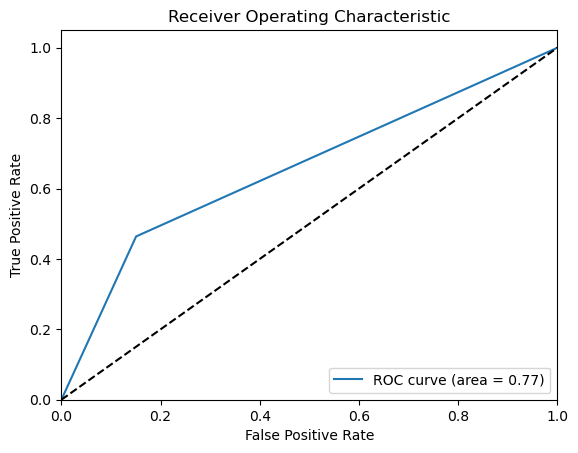

In [82]:
#  ROC curves
fpr, tpr, thresholds = roc_curve(test_actual_labels, test_predicted_labels)
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## Conclusion

### Part 1: Customer Segmentation Results

Using K-Means clustering evaluated by two metrics—Silhouette Score (optimal k=6, score ≈ 0.28) and Calinski-Harabasz Index (optimal k=4, score ≈ 21,800)—k=5 was selected as a business-driven compromise between granularity and segment size, yielding 5 distinct customer segments:

| Segment | Count | % | Key Traits | Marketing Strategy |
|---|---|---|---|---|
| General Developmental | 24,611 | 39.7% | Recently flew but low tenure/frequency | Brand promotion & onboarding |
| High-Value | 15,728 | 25.3% | Long tenure + still active | Rewards & loyalty perks |
| Potential Churn | 12,111 | 19.5% | Long gap since last flight | Targeted coupons to re-engage |
| VIP | 5,337 | 8.6% | Longest tenure + highest miles | Premium services & ambassador program |
| Important Retention | 4,257 | 6.9% | Heavy discount dependence | Tiered discount retention |

### Part 2: Churn Prediction Results

Built LSTM model to predict churn for High-Value Customers (15,728):

- **Accuracy:** 0.71
- **AUC:** 0.77
- **Log Loss:** 0.54


The model identifies high-value customers at risk of churning, so the airline can step in with targeted retention campaigns:)

### Business Recommendations

1. **VIP Customers (8.6%):** Provide premium services and word-of-mouth program
2. **High-Value Customers (25.3%):** Maintain loyalty through rewards
3. **Potential Churn (19.5%):** Immediate intervention with targeted coupons and churn-cause analysis
4. **Important Retention (6.9%):** Deploy retention campaigns before discount dependence lapses
5. **General Developmental (39.6%):** Brand awareness and new customer promotions